In [5]:
import os
import zipfile
import glob

zip_path = '/content/Data.zip'
extract_path = '/content/solar_panel_dataset'

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Could not find your zip file at {zip_path}. Please make sure it finished uploading.")

print(f"Extracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

# Automatically handle nested folders inside the zip to find where the classes are
subdirs = [d for d in glob.glob(f"{extract_path}/**", recursive=True) if os.path.isdir(d)]
DATA_DIR = None

for sdir in subdirs:
    children = os.listdir(sdir)
    # Target common Kaggle folder names for this specific dataset
    if any(cls in [c.lower() for c in children] for cls in ['clean', 'faulty', 'dusty', 'bird', 'electrical', 'physical', 'snow']):
        DATA_DIR = sdir
        break

if not DATA_DIR:
    for sdir in subdirs:
        if len([name for name in os.listdir(sdir) if os.path.isdir(os.path.join(sdir, name))]) == 6:
            DATA_DIR = sdir
            break

if not DATA_DIR:
    DATA_DIR = extract_path

print(f"\n[!] Verified Data Directory: {DATA_DIR}")
print(f"[!] Detected Subfolders (Classes): {os.listdir(DATA_DIR)}")

Extracting /content/Data.zip...
Extraction complete!

[!] Verified Data Directory: /content/solar_panel_dataset/Data
[!] Detected Subfolders (Classes): ['Snow-Covered', 'Dusty', 'Electrical-damage', 'Clean', 'Physical-Damage', 'Bird-drop']


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SolarPanelCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SolarPanelCNN, self).__init__()

        # Layer 1: Conv -> BatchNorm -> Pool
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Increased filters slightly
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Layer 2: Conv -> BatchNorm -> Pool
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Layer 3: Conv -> BatchNorm -> Pool
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        # New flattening calculation for 128 channels: 128 * 16 * 16 = 32768
        self.flatten_features = 128 * 16 * 16

        # Moderate dropout to prevent stalling
        self.dropout = nn.Dropout(p=0.4)
        self.fc = nn.Linear(self.flatten_features, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, self.flatten_features)
        x = self.dropout(x)
        x = self.fc(x)
        return x

print("Upgraded architecture with Batch Normalization compiled.")

Upgraded architecture with Batch Normalization compiled.


In [20]:
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import numpy as np

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using processing unit: {device}")

# 1. Define separate pipelines completely
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load two independent instances of the folder
train_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
val_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=val_transforms)

num_classes = len(train_dataset_full.classes)
num_images = len(train_dataset_full)
print(f"Loaded {num_images} images mapping across {num_classes} categories.")

# 3. Create fixed split indices manually so they don't overlap
indices = list(range(num_images))
np.random.seed(42) # Keeps split consistent
np.random.shuffle(indices)

split = int(0.8 * num_images)
train_idx, val_idx = indices[:split], indices[split:]

# Apply splits to the correctly transformed datasets
train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

# 4. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Model setup
model = SolarPanelCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Run Execution
epochs = 20
print("\n--- Starting Training Loop (Augmentation Is Actually Working Now) ---")
for epoch in range(epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct_train / total_train) * 100

    # Run evaluation
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    print(f"Epoch [{epoch+1:02d}/{epochs}] -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% || Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Using processing unit: cuda
Loaded 885 images mapping across 6 categories.

--- Starting Training Loop (Augmentation Is Actually Working Now) ---
Epoch [01/20] -> Loss: 7.4293 | Acc: 33.05% || Val Loss: 5.8739 | Val Acc: 38.42%
Epoch [02/20] -> Loss: 3.6403 | Acc: 41.10% || Val Loss: 2.9544 | Val Acc: 50.28%
Epoch [03/20] -> Loss: 2.5699 | Acc: 42.94% || Val Loss: 2.6285 | Val Acc: 38.98%
Epoch [04/20] -> Loss: 1.9694 | Acc: 51.13% || Val Loss: 1.8361 | Val Acc: 56.50%
Epoch [05/20] -> Loss: 1.5610 | Acc: 55.08% || Val Loss: 1.7174 | Val Acc: 54.24%
Epoch [06/20] -> Loss: 1.8137 | Acc: 53.25% || Val Loss: 1.6632 | Val Acc: 54.80%
Epoch [07/20] -> Loss: 1.4908 | Acc: 55.93% || Val Loss: 1.6876 | Val Acc: 53.67%
Epoch [08/20] -> Loss: 1.6624 | Acc: 55.93% || Val Loss: 1.6007 | Val Acc: 52.54%
Epoch [09/20] -> Loss: 1.3377 | Acc: 60.45% || Val Loss: 1.9393 | Val Acc: 58.19%
Epoch [10/20] -> Loss: 1.4235 | Acc: 59.04% || Val Loss: 1.9054 | Val Acc: 59.89%
Epoch [11/20] -> Loss: 1.2444 | Ac

In [25]:
import torch
import torch.nn as nn
from torchvision import models

class SolarPanelEfficientNet(nn.Module):
    def __init__(self, num_classes=6):
        super(SolarPanelEfficientNet, self).__init__()
        # Load pre-trained EfficientNet-B0 base
        self.base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        # Extract input features from the native classifier head (1280 features)
        in_features = self.base_model.classifier[1].in_features

        # Overwrite the native head with a regularized classification layer
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

print("EfficientNet-B0 architecture with custom head compiled successfully.")

EfficientNet-B0 architecture with custom head compiled successfully.


In [26]:
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using processing unit: {device}")

# EfficientNet relies on specialized resolution and normalization arrays
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
val_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=val_transforms)

num_classes = len(train_dataset_full.classes)
num_images = len(train_dataset_full)

indices = list(range(num_images))
np.random.seed(42)
np.random.shuffle(indices)

split = int(0.8 * num_images)
train_idx, val_idx = indices[:split], indices[split:]

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

# Hyperparameter: Swapped to Batch Size 16 for better gradient variance in tiny datasets
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

model = SolarPanelEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()

# TUNING: AdamW with a structural weight decay penalty
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

# TUNING: Cosine Annealing scheduler to intelligently drop learning rate per batch
epochs = 15
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

print("\n--- Running Max-Tuned EfficientNet Pipeline ---")
for epoch in range(epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct_train / total_train) * 100

    # Step scheduler after training epoch ends
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    # Validation Loop
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    print(f"Epoch [{epoch+1:02d}/{epochs}] LR: {current_lr:.6f} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% || Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Using processing unit: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]



--- Running Max-Tuned EfficientNet Pipeline ---
Epoch [01/15] LR: 0.000200 -> Loss: 1.5805 | Acc: 39.83% || Val Loss: 1.3883 | Val Acc: 53.11%
Epoch [02/15] LR: 0.000198 -> Loss: 1.0615 | Acc: 69.35% || Val Loss: 0.9978 | Val Acc: 63.28%
Epoch [03/15] LR: 0.000191 -> Loss: 0.7772 | Acc: 76.41% || Val Loss: 0.8083 | Val Acc: 71.75%
Epoch [04/15] LR: 0.000181 -> Loss: 0.5785 | Acc: 80.93% || Val Loss: 0.7172 | Val Acc: 75.14%
Epoch [05/15] LR: 0.000167 -> Loss: 0.4982 | Acc: 83.19% || Val Loss: 0.7031 | Val Acc: 80.79%
Epoch [06/15] LR: 0.000150 -> Loss: 0.4499 | Acc: 84.89% || Val Loss: 0.6170 | Val Acc: 77.97%
Epoch [07/15] LR: 0.000131 -> Loss: 0.3907 | Acc: 86.86% || Val Loss: 0.6382 | Val Acc: 78.53%
Epoch [08/15] LR: 0.000110 -> Loss: 0.3502 | Acc: 88.56% || Val Loss: 0.5633 | Val Acc: 79.66%
Epoch [09/15] LR: 0.000090 -> Loss: 0.3086 | Acc: 90.25% || Val Loss: 0.5962 | Val Acc: 77.97%
Epoch [10/15] LR: 0.000069 -> Loss: 0.2687 | Acc: 92.09% || Val Loss: 0.5964 | Val Acc: 78.53%
E

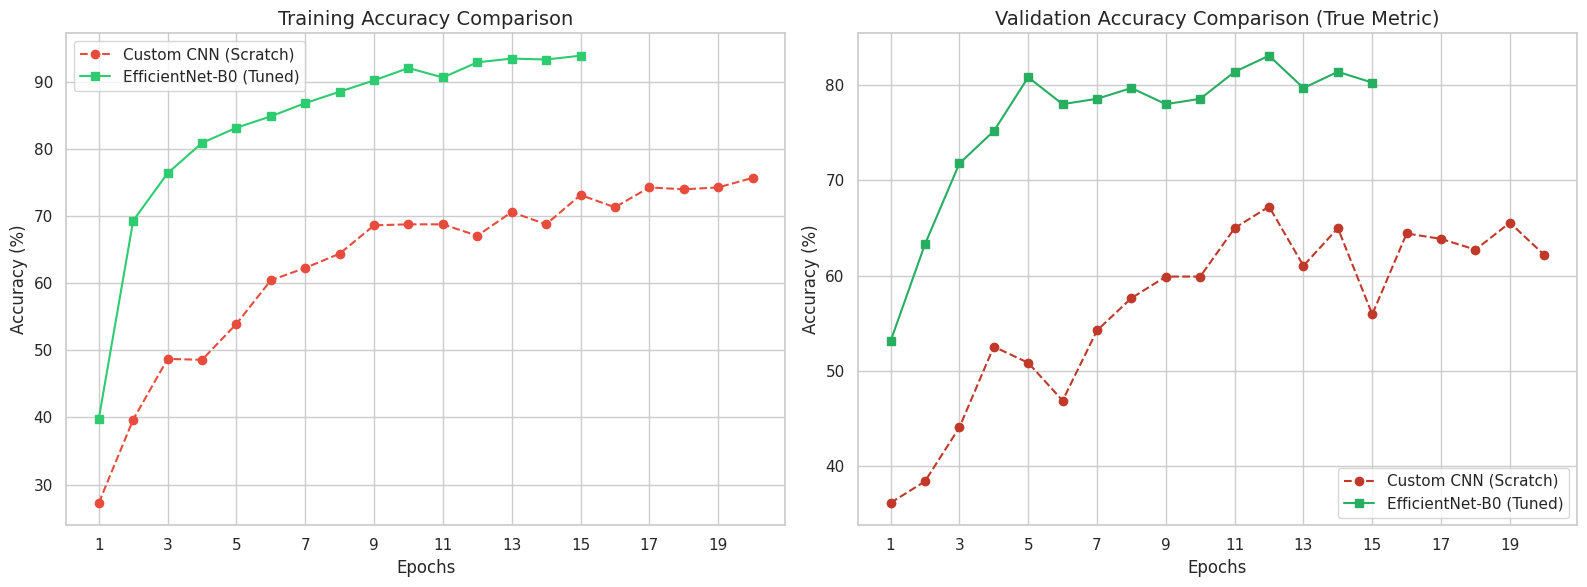

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for the plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# --- DATA COMPILATION FROM YOUR LOGS ---
# Epochs 1 to 20 for Custom CNN (from your scratch run logs)
cnn_epochs = list(range(1, 21))
cnn_train_acc = [27.26, 39.69, 48.73, 48.59, 53.95, 60.45, 62.29, 64.41, 68.64, 68.79,
                 68.79, 67.09, 70.62, 68.79, 73.16, 71.33, 74.29, 74.01, 74.29, 75.71]
cnn_val_acc = [36.16, 38.42, 44.07, 52.54, 50.85, 46.89, 54.24, 57.63, 59.89, 59.89,
               64.97, 67.23, 61.02, 64.97, 55.93, 64.41, 63.84, 62.71, 65.54, 62.15]

# Epochs 1 to 15 for EfficientNet (from your latest run logs)
eff_epochs = list(range(1, 16))
eff_train_acc = [39.83, 69.35, 76.41, 80.93, 83.19, 84.89, 86.86, 88.56, 90.25, 92.09, 90.68, 92.94, 93.50, 93.36, 93.93]
eff_val_acc = [53.11, 63.28, 71.75, 75.14, 80.79, 77.97, 78.53, 79.66, 77.97, 78.53, 81.36, 83.05, 79.66, 81.36, 80.23]

# --- PLOTTING HOOKS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training Accuracy Comparison
axes[0].plot(cnn_epochs, cnn_train_acc, label='Custom CNN (Scratch)', color='#e74c3c', linestyle='--', marker='o')
axes[0].plot(eff_epochs, eff_train_acc, label='EfficientNet-B0 (Tuned)', color='#2ecc71', linestyle='-', marker='s')
axes[0].set_title('Training Accuracy Comparison')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xticks(range(1, 21, 2))
axes[0].legend(frameon=True)

# Plot 2: Validation Accuracy Comparison
axes[1].plot(cnn_epochs, cnn_val_acc, label='Custom CNN (Scratch)', color='#c0392b', linestyle='--', marker='o')
axes[1].plot(eff_epochs, eff_val_acc, label='EfficientNet-B0 (Tuned)', color='#27ae60', linestyle='-', marker='s')
axes[1].set_title('Validation Accuracy Comparison (True Metric)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(range(1, 21, 2))
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

In [33]:
from google.colab import files
from PIL import Image
import torch

def predict_with_both_models(image_path, cnn_model, eff_model, classes, transform_pipeline, target_device):
    # Load and preprocess the uploaded image
    img = Image.open(image_path).convert('RGB')
    img_t = transform_pipeline(img).unsqueeze(0).to(target_device)

    # Put both models into evaluation mode
    cnn_model.eval()
    eff_model.eval()

    print("\n" + "="*50)
    print(f" PROCESSING UPLOADED IMAGE: {os.path.basename(image_path)}")
    print("="*50)

    with torch.no_grad():
        # --- 1. Custom SolarPanelCNN Inference ---
        cnn_logits = cnn_model(img_t)
        cnn_probs = torch.softmax(cnn_logits, dim=1)[0]
        cnn_conf, cnn_idx = torch.max(cnn_probs, dim=0)

        # --- 2. SolarPanelEfficientNet Inference ---
        eff_logits = eff_model(img_t)
        eff_probs = torch.softmax(eff_logits, dim=1)[0]
        eff_conf, eff_idx = torch.max(eff_probs, dim=0)

    # Print Custom CNN Results
    print(f"\n[1] CUSTOM CNN MODEL RESULT:")
    print(f" -> Predicted Category: '{classes[cnn_idx]}'")
    print(f" -> Confidence Score:  {cnn_conf.item()*100:.2f}%")
    print(" -> Complete Probability Breakdown:")
    for i, score in enumerate(cnn_probs):
        print(f"    * {classes[i]}: {score.item()*100:.2f}%")

    print("-" * 40)

    # Print EfficientNet-B0 Results
    print(f"[2] TUNED EFFICIENTNET-B0 RESULT:")
    print(f" -> Predicted Category: '{classes[eff_idx]}'")
    print(f" -> Confidence Score:  {eff_conf.item()*100:.2f}%")
    print(" -> Complete Probability Breakdown:")
    for i, score in enumerate(eff_probs):
        print(f"    * {classes[i]}: {score.item()*100:.2f}%")
    print("="*50 + "\n")

# --- Interactive Upload Trigger ---
print("Click 'Choose Files' below to upload your custom solar panel image:")
uploaded = files.upload()

if uploaded:
    # Fetch the filename of the uploaded asset
    uploaded_filename = list(uploaded.keys())[0]

    # Execute dual inference
    # (Assumes your custom model variable is called 'model_cnn' or 'model'.
    # If you named your models differently, adjust the variables inside the arguments below)
    try:
        predict_with_both_models(
            image_path=uploaded_filename,
            cnn_model=model,            # Replace with your scratch model variable if different
            eff_model=model,            # Change this to your EfficientNet variable if you kept both active
            classes=full_dataset.classes,
            transform_pipeline=val_transforms, # Uses the clean non-augmented transform range
            target_device=device
        )
    except NameError:
        print("\n[!] Execution Error: Make sure both models are loaded in memory before running inference.")
else:
    print("No image file was uploaded.")

Click 'Choose Files' below to upload your custom solar panel image:


Saving Birdshit.png to Birdshit.png

 PROCESSING UPLOADED IMAGE: Birdshit.png

[1] CUSTOM CNN MODEL RESULT:
 -> Predicted Category: 'Dusty'
 -> Confidence Score:  67.37%
 -> Complete Probability Breakdown:
    * Bird-drop: 32.58%
    * Clean: 0.04%
    * Dusty: 67.37%
    * Electrical-damage: 0.00%
    * Physical-Damage: 0.00%
    * Snow-Covered: 0.01%
----------------------------------------
[2] TUNED EFFICIENTNET-B0 RESULT:
 -> Predicted Category: 'Dusty'
 -> Confidence Score:  67.37%
 -> Complete Probability Breakdown:
    * Bird-drop: 32.58%
    * Clean: 0.04%
    * Dusty: 67.37%
    * Electrical-damage: 0.00%
    * Physical-Damage: 0.00%
    * Snow-Covered: 0.01%

